The sleep-edf database contains 197 whole-night PolySomnoGraphic sleep recordings, containing EEG, EOG, chin EMG, and event markers. Some records also contain respiration and body temperature. Corresponding hypnograms (sleep patterns) were manually scored by well-trained technicians according to the Rechtschaffen and Kales manual, and are also available.

1. Metadata and Time Tracking
These columns identify the source of the data and the specific time window (epoch) being analyzed.

- recording_id: A unique identifier for the specific night and subject (e.g., SC4001E0 refers to Sleep Cassette subject 00, night 1).
- epoch: The sequential number of the 30-second window in the recording.
- epoch_start_sec / epoch_end_sec: The exact start and end time of that 30-second window in seconds from the beginning of the recording.
- sleep_stage: The target label for analysis. These were manually scored by technicians according to the Rechtschaffen and Kales manual. Common values include:
- W: Wake.
- R: REM (Rapid Eye Movement).
- 1, 2, 3, 4: Non-REM sleep stages.
- psg_file / hyp_file: The names of the original source EDF files for the raw signals (PSG) and annotations (Hypnogram).

2. Physiological Signal Features
For each 30-second epoch, three statistical features (mean, std, and rms) have been calculated for the primary sensors.

- EEG (Electroencephalogram) - Brain Activity
The EEG measures electrical activity in the brain. The dataset includes two specific electrode locations suggested for this study.
- EEG Fpz-Cz: Recorded from the forehead (Fpz) to the center of the head (Cz). This is often the primary channel for identifying sleep stages.
- EEG Pz-Oz: Recorded from the back of the head.
- EOG (Electrooculogram) - Eye Movement
EOG horizontal: Measures horizontal eye movements. This is critical for identifying the Rapid Eye Movement (REM) sleep stage.
- EMG (Electromyogram) - Muscle Tone
EMG submental: Measures muscle activity from the chin. During REM sleep, muscle tone typically drops to its lowest level (atonia).

In [5]:
!pip install boto3 pandas requests

  Using cached boto3-1.42.27-py3-none-any.whl.metadata (6.8 kB)
  Using cached botocore-1.42.27-py3-none-any.whl.metadata (5.9 kB)
  Using cached jmespath-1.0.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached s3transfer-0.16.0-py3-none-any.whl.metadata (1.7 kB)
Using cached boto3-1.42.27-py3-none-any.whl (140 kB)
Using cached botocore-1.42.27-py3-none-any.whl (14.6 MB)
Using cached jmespath-1.0.1-py3-none-any.whl (20 kB)
Using cached s3transfer-0.16.0-py3-none-any.whl (86 kB)

   ---------------------------------------- 0/4 [jmespath]
   ---------------------------------------- 0/4 [jmespath]
   ---------- ----------------------------- 1/4 [botocore]
   ---------- ----------------------------- 1/4 [botocore]
   ---------- ----------------------------- 1/4 [botocore]
   ---------- ----------------------------- 1/4 [botocore]
   ---------- ----------------------------- 1/4 [botocore]
   ---------- ----------------------------- 1/4 [botocore]
   ---------- ----------------------------- 

In [29]:
import pandas as pd
import os

# Load the local file
file_path = '../datasets/sleepedf_SC_merged_epochs.csv'
# Check if the file exists before trying to read it
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Data loaded successfully!")
    print(df.head())
else:
    print(f"Error: Could not find the file at {file_path}")
    print(f"Current Working Directory: {os.getcwd()}")

# Display the columns and the first few rows
print("Columns in the dataset:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Data loaded successfully!
  recording_id  epoch  epoch_start_sec  epoch_end_sec sleep_stage  \
0     SC4001E0      0                0             30           W   
1     SC4001E0      1               30             60           W   
2     SC4001E0      2               60             90           W   
3     SC4001E0      3               90            120           W   
4     SC4001E0      4              120            150           W   

   EEG Fpz-Cz_mean  EEG Fpz-Cz_std  EEG Fpz-Cz_rms  EEG Pz-Oz_mean  \
0     4.087560e-07        0.000036        0.000036   -3.101700e-07   
1    -5.228151e-07        0.000026        0.000026   -4.021419e-07   
2     9.948366e-07        0.000032        0.000032   -3.691600e-07   
3    -2.231795e-07        0.000018        0.000018   -1.439807e-07   
4     1.761055e-07        0.000017        0.000017   -1.639426e-07   

   EEG Pz-Oz_std  EEG Pz-Oz_rms  EOG horizontal_mean  EOG horizontal_std  \
0       0.000007       0.000007        -2.633174e-07          

In [30]:
# Check study distribution
df['study_type'] = df['recording_id'].str[:2]
print("Recordings per study:")
print(df.groupby('study_type')['recording_id'].nunique())

Recordings per study:
study_type
SC    153
Name: recording_id, dtype: int64


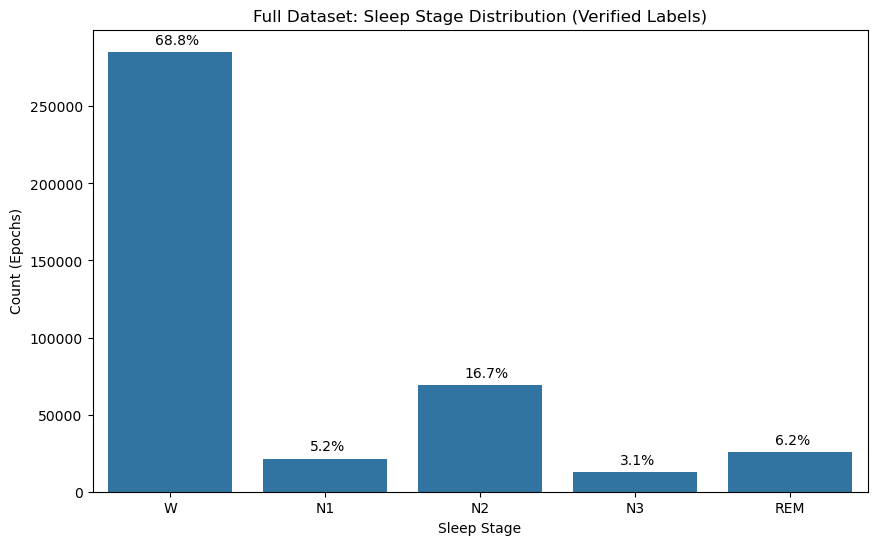

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the correct order based on your verified labels
correct_order = ['W', 'N1', 'N2', 'N3', 'REM']

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sleep_stage', order=correct_order)

plt.title("Full Dataset: Sleep Stage Distribution (Verified Labels)")
plt.xlabel("Sleep Stage")
plt.ylabel("Count (Epochs)")

# Optional: Add the percentage on top of each bar
total = len(df)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height() + 5000
    plt.annotate(percentage, (x, y))

plt.show()

In [32]:
# Create the table based on the actual labels found in your 'sleep_stage' column
stage_counts = df['sleep_stage'].value_counts()
target_order = ['W', 'N1', 'N2', 'N3', 'REM']

stage_table = pd.DataFrame({
    'Count (Epochs)': stage_counts.reindex(target_order, fill_value=0),
    'Percentage (%)': (stage_counts.reindex(target_order, fill_value=0) / len(df) * 100).round(2)
})

print("Full Dataset: Verified Sleep Stage Counts")
print(stage_table)

Full Dataset: Verified Sleep Stage Counts
             Count (Epochs)  Percentage (%)
sleep_stage                                
W                    285433           68.79
N1                    21522            5.19
N2                    69132           16.66
N3                    13039            3.14
REM                   25835            6.23


Average recording length: 22.60 hours


Text(0.5, 1.0, 'Distribution of Recording Durations')

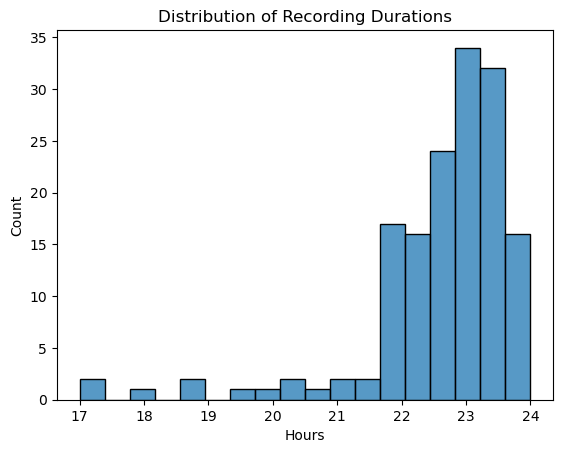

In [33]:
# Calculate hours per recording
epochs_per_rec = df.groupby('recording_id').size()
hours_per_rec = (epochs_per_rec * 30) / 3600

print(f"Average recording length: {hours_per_rec.mean():.2f} hours")
sns.histplot(hours_per_rec)
plt.xlabel("Hours")
plt.title("Distribution of Recording Durations")

Text(0.5, 1.0, 'EMG Muscle Energy (rms) by Stage')

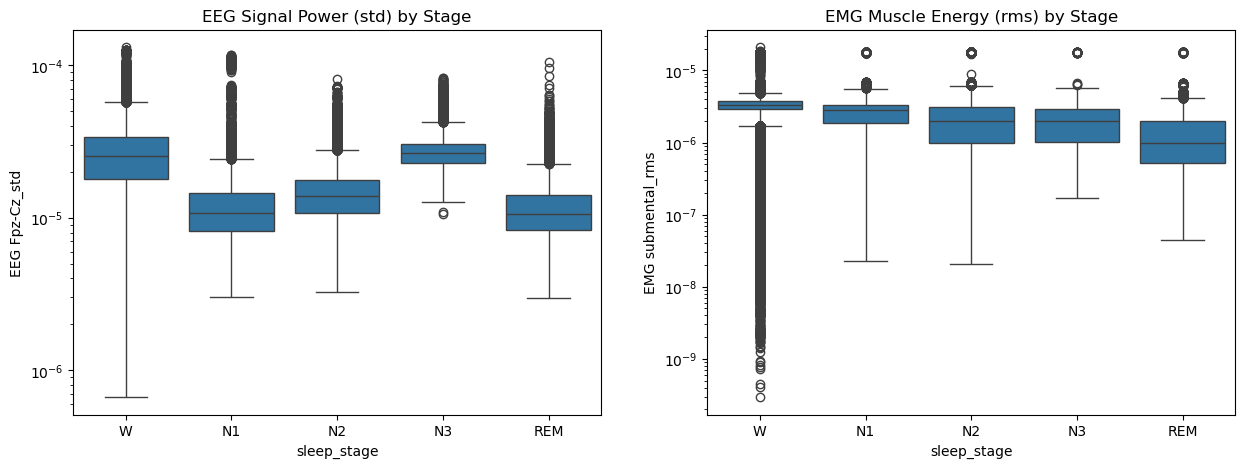

In [34]:
# Compare EEG and EMG distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='sleep_stage', y='EEG Fpz-Cz_std', ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_title("EEG Signal Power (std) by Stage")

sns.boxplot(data=df, x='sleep_stage', y='EMG submental_rms', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title("EMG Muscle Energy (rms) by Stage")

In [35]:
# Use the verified label 'REM' instead of 'R'
rem_counts = df[df['sleep_stage'] == 'REM'].groupby('recording_id').size()

# Use the verified label 'N3' instead of '3' or '4'
n3_counts = df[df['sleep_stage'] == 'N3'].groupby('recording_id').size()

# Threshold: 30 epochs * 30 seconds = 15 minutes
print("Recordings with less than 15 mins of REM:")
print(rem_counts[rem_counts < 30])

print("\nRecordings with less than 15 mins of N3:")
print(n3_counts[n3_counts < 30])

Recordings with less than 15 mins of REM:
recording_id
SC4351F0    24
dtype: int64

Recordings with less than 15 mins of N3:
recording_id
SC4101E0     6
SC4102E0    25
SC4201E0     4
SC4231E0    12
SC4232E0     1
SC4242E0     5
SC4251E0    22
SC4322E0     1
SC4371F0    11
SC4372F0     6
SC4381F0    16
SC4401E0     4
SC4461F0     9
SC4462F0    19
SC4491G0    14
SC4492G0    27
SC4501E0     2
SC4511E0     3
SC4512E0     2
SC4522E0    11
SC4532E0    21
SC4541F0     5
SC4552F0     1
SC4562F0    28
SC4572F0    29
SC4581G0    10
SC4582G0     6
SC4621E0    14
SC4622E0     4
SC4632E0    28
SC4671G0    17
SC4672G0    29
SC4711E0     4
SC4752E0    20
SC4761E0    27
SC4771G0     5
SC4801G0    13
SC4802G0     6
dtype: int64


In [37]:
import pandas as pd

# 1. Initial Filtering for SC Study
df_sc = df[df['recording_id'].str.startswith('SC')].copy()
df_sc['subject_id'] = df_sc['recording_id'].str[3:5]

# 2. DROP subjects 13, 36, and 52
# We use strings because subject_id was extracted from the recording_id string
exclude_ids = ['13', '36', '52']
df_sc = df_sc[~df_sc['subject_id'].isin(exclude_ids)]

print(f"Total subjects remaining after manual drop: {df_sc['subject_id'].nunique()}")

# 3. Compute sleep-stage proportions per SUBJECT
subject_props = (
    df_sc.groupby('subject_id')['sleep_stage']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# 4. Remove "bad" subjects (those with < 5% REM or N3)
min_threshold = 5.0
valid_subjects = subject_props[
    (subject_props['REM'] >= min_threshold) & 
    (subject_props['N3'] >= min_threshold)
]

# 5. Select 15 subjects with most representative healthy sleep (sorting by N2 and REM)
stratified_selection = valid_subjects.sort_values(by=['N2', 'REM'], ascending=False).head(15)
chosen_ids = stratified_selection.index.tolist()

# 6. Final Dataframe containing all epochs for the chosen 15
final_sample_df = df_sc[df_sc['subject_id'].isin(chosen_ids)].copy()

print(f"Successfully selected 15 subjects: {chosen_ids}")

Total subjects remaining after manual drop: 75
Successfully selected 15 subjects: ['65', '09', '17', '28', '16', '27', '82', '15', '14', '07', '59', '31', '00', '45', '08']


In [39]:
# Save the 15-subject stratified and cropped dataset
output_path = '../datasets/sleepedf_15_stratified_cropped.csv'

final_cropped_df.to_csv(output_path, index=False)

print(f"File saved successfully at: {output_path}")
print(f"Total Epochs saved: {len(final_cropped_df)}")

File saved successfully at: ../datasets/sleepedf_15_stratified_cropped.csv
Total Epochs saved: 36708


In [40]:
# Create a summary of the 15 selected subjects
summary_table = valid_subjects.loc[chosen_ids]

# Calculate the group average to see the 'Target Profile'
summary_table.loc['GROUP_AVERAGE'] = summary_table.mean()

print("Final 15 Subjects: Sleep Stage Proportions (%)")
print(summary_table.round(2))

Final 15 Subjects: Sleep Stage Proportions (%)
sleep_stage      N1     N2     N3    REM      W
subject_id                                     
65             5.34  22.53   5.72   6.49  59.92
09             2.10  22.52   5.81  10.43  59.14
17             1.19  18.59   7.38   7.82  65.02
28             2.80  17.92   5.43   5.98  67.87
16             1.81  16.89   5.46   8.47  67.38
27             2.99  16.08   6.42   7.48  67.02
82             3.38  14.59   5.75   7.36  68.92
15             1.61  14.47   6.48   9.13  68.31
14             1.01  14.29   5.35   8.07  71.28
07             3.10  14.25   6.88   6.56  69.21
59             8.09  13.17   5.31   8.50  64.93
31             4.30  12.96   5.66   6.20  70.88
00             2.14  11.37   9.44   6.21  70.85
45             7.27  11.28  10.51   5.99  64.95
08             1.97  10.88  11.64   7.20  68.31
GROUP_AVERAGE  3.27  15.45   6.88   7.46  66.93


In [26]:
def crop_sleep_period(df, buffer_epochs=60):
    cropped_dfs = []
    
    for rec_id in df['recording_id'].unique():
        night_data = df[df['recording_id'] == rec_id].sort_values('epoch')
        
        # Find indices of all non-Wake epochs
        non_wake_idx = night_data[night_data['sleep_stage'] != 'W'].index
        
        if len(non_wake_idx) > 0:
            # Find the first and last sleep epoch
            start_pos = max(0, night_data.index.get_loc(non_wake_idx[0]) - buffer_epochs)
            end_pos = min(len(night_data), night_data.index.get_loc(non_wake_idx[-1]) + buffer_epochs)
            
            cropped_night = night_data.iloc[start_pos:end_pos]
            cropped_dfs.append(cropped_night)
            
    return pd.concat(cropped_dfs)

# Apply the crop to your stratified 15 subjects
final_cropped_df = crop_sleep_period(final_sample_df)

print(f"Original epochs: {len(final_sample_df)}")
print(f"Cropped epochs: {len(final_cropped_df)}")
print("\nNew Distribution after Cropping:")
print(final_cropped_df['sleep_stage'].value_counts(normalize=True).round(4) * 100)

Original epochs: 78305
Cropped epochs: 36708

New Distribution after Cropping:
sleep_stage
N2     33.76
W      29.56
REM    15.76
N3     13.89
N1      7.03
Name: proportion, dtype: float64


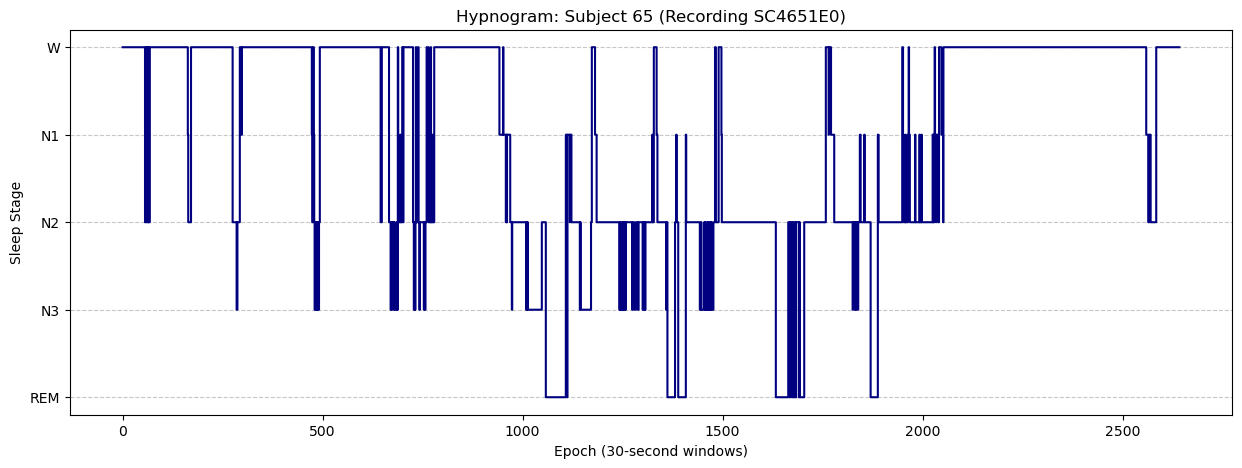

In [27]:
def plot_hypnogram(df, subject_id):
    # Filter for one specific night of a subject
    subject_data = df[df['subject_id'] == subject_id].iloc[:]
    first_night = subject_data['recording_id'].unique()[0]
    night_df = subject_data[subject_data['recording_id'] == first_night].sort_values('epoch')

    # Map stages to numbers for plotting (standard order)
    mapping = {'W': 0, 'N1': -1, 'N2': -2, 'N3': -3, 'REM': -4}
    night_df['stage_num'] = night_df['sleep_stage'].map(mapping)

    plt.figure(figsize=(15, 5))
    plt.step(night_df['epoch'], night_df['stage_num'], where='post', color='navy')
    
    plt.yticks([0, -1, -2, -3, -4], ['W', 'N1', 'N2', 'N3', 'REM'])
    plt.title(f"Hypnogram: Subject {subject_id} (Recording {first_night})")
    plt.xlabel("Epoch (30-second windows)")
    plt.ylabel("Sleep Stage")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Plot the first subject in your list
plot_hypnogram(final_cropped_df, chosen_ids[0])

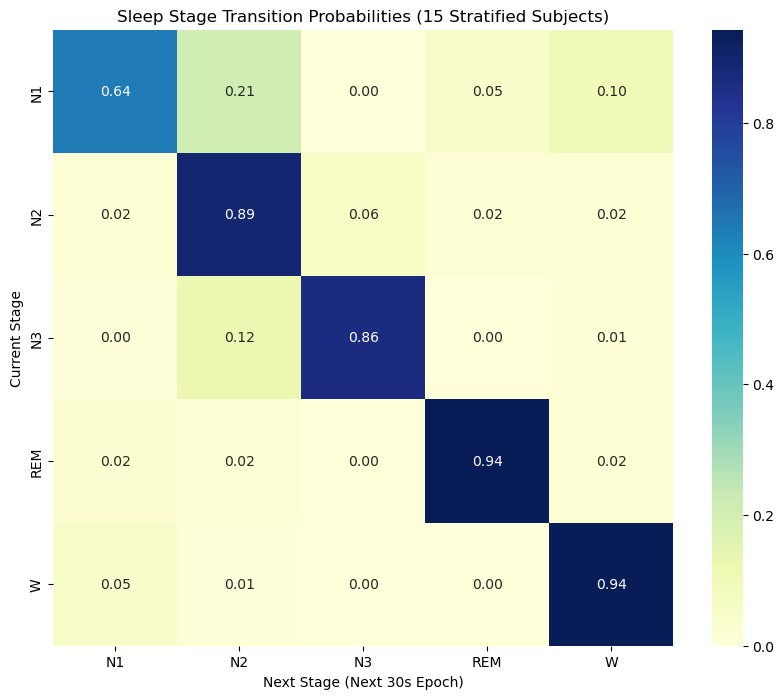

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a 'next_stage' column by shifting the sleep_stage per recording
final_cropped_df = final_cropped_df.sort_values(['recording_id', 'epoch'])
final_cropped_df['next_stage'] = final_cropped_df.groupby('recording_id')['sleep_stage'].shift(-1)

# 2. Create the transition matrix (normalized by row to get probabilities)
transition_matrix = pd.crosstab(
    final_cropped_df['sleep_stage'], 
    final_cropped_df['next_stage'], 
    normalize='index'
)

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title("Sleep Stage Transition Probabilities (15 Stratified Subjects)")
plt.ylabel("Current Stage")
plt.xlabel("Next Stage (Next 30s Epoch)")
plt.show()